In [ ]:
!pip install "matplotlib==3.11.0" "pylatexenc==2.10" "qiskit==2.1.2" "qiskit-aer==0.17.2" "iqm-client[qiskit]==34.0.3" "iqm-qubit-selector==1.0.3"

Running circuits locally emulated works for a while until the circuit size grows and the local resources cannot handle those any more. Moreover, to explore what hardware can do and have a real understanding on what those devices can do for us, you better start exploring the usage of real quantum hardware trough some of the many providers out there.

# IQM Resonance

[IQM Resonance](https://iqm.tech/products/iqm-resonance/) is the cloud based access to IQM's devices (Emerald, Garnet and Sirius)

![alt](https://github.com/IraitzM/qml-dpg-2026/blob/main/Session%202/public/image.png?raw=1)

This devices offer quite different topologies so make sure you pay attention when exploring those. Let's start by defining a simple circuit to run on such hardware devices.

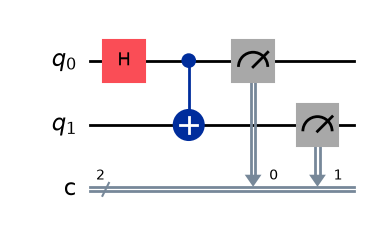

In [1]:
from qiskit import QuantumCircuit

circuit = QuantumCircuit(2, 2)

circuit.h(0)
circuit.cx(0,1)

circuit.measure([0,1], [0,1])

circuit.draw('mpl')

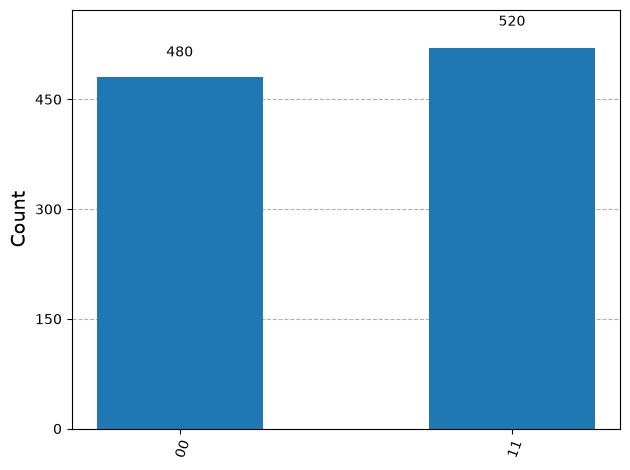

In [2]:
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# execute the quantum circuit
simulator = AerSimulator()

result = simulator.run(circuit, shots=1000).result()
counts  = result.get_counts(circuit)

plot_histogram(counts)

Cool! Now let's see what we get when runing on a real hardware. For that we will first need to connect to IQM service using their library and an authentication TOKEN that allows the notebook to impersonate me.

In [3]:
import os
from getpass import getpass

os.environ["IQM_TOKEN"] = getpass("Here goes your IQM API token:")

Here goes your IQM API token:··········


In [4]:
from iqm.qiskit_iqm import IQMProvider

IQM_URL = "https://resonance.meetiqm.com/"
QUANTUM_COMPUTER = "emerald"

provider = IQMProvider(IQM_URL, quantum_computer=QUANTUM_COMPUTER)
backend = provider.get_backend()
print(f"Connected to : {backend.name}")

Connected to : IQMBackend


We can look for information about the calibration data, errors and such...

In [ ]:
import matplotlib.pyplot as plt
from iqm.qubit_selector.qubit_selector import CalibrationDataManager, CalibrationType

calibration_data = CalibrationDataManager().get_calibration_fidelities(backend)

def plot_calibration_data(key, data):
    two_qubit_keys = [CalibrationType.CZ.value, CalibrationType.CLIFFORD.value]
    coherence_keys = [CalibrationType.T1.value, CalibrationType.T2.value]
    every_second = key in two_qubit_keys
    coherence = key in coherence_keys
    xlabel = 'Pairs' if key in two_qubit_keys else 'Qubits'
    ylabel = 'Error' if key not in coherence_keys else 'Coherence in (us)'
    pairs = list(data.items())
    if every_second:
        pairs = pairs[::2]
    labels = [pair[0] for pair in pairs]

    if coherence:
        values = [pair[1] for pair in pairs]
    else:
        values = [1-pair[1] for pair in pairs]

    plt.figure(figsize=(12, 6))
    plt.bar(labels, values)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(f'{key} metrics')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

for k, v in calibration_data.items():
    plot_calibration_data(k, v)

This is some crucial information as it tells us what gates are available to the device and what fidelity or trust we can have when performing our set of operations. Thus, in order to be able to run our circuit we need to translate to the device native set of gates our proposed circuit.

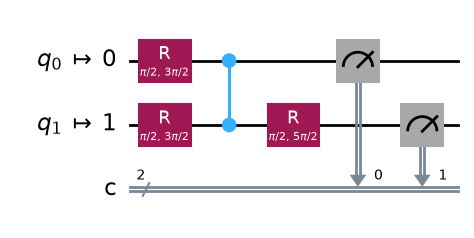

In [6]:
from qiskit import transpile

# Propose a set of qubits to place the circuit in
initial_layout = list(range(circuit.num_qubits))

circ_iqm = transpile(
    circuit,
    backend=backend,
    initial_layout=initial_layout,
    optimization_level=3,
    seed_transpiler=42
)

circ_iqm.draw("mpl", fold=-1)

We can see here some of the differences between the proposed theoretical and actual circuit runing on the device.

In [7]:
hw_job = backend.run(circ_iqm, shots=1000)
print(f"Standard Job ID: {hw_job.job_id()} with status {hw_job.status()}")

Standard Job ID: 019ec0cf-e0ef-7ac0-b812-4be4d52bd2e4 with status JobStatus.QUEUED


Queued means there might be people submitting jobs to the same device, so we will need to wait until it finishes.

In [8]:
counts_hw_std = hw_job.result().get_counts()

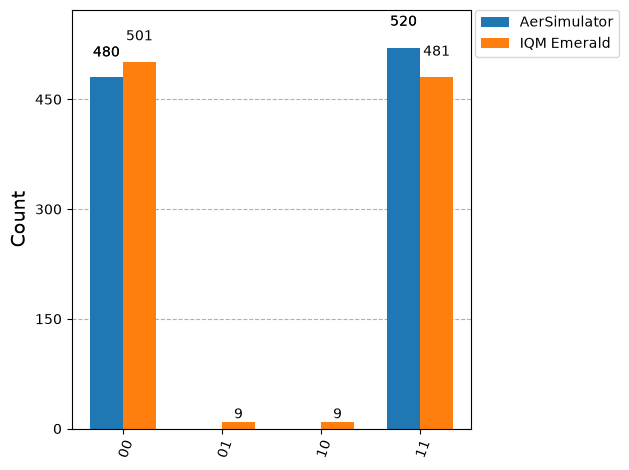

In [9]:
plot_histogram([counts, counts_hw_std], legend=["AerSimulator", "IQM Emerald"])

Not perfect but there is some evident similarities. The readout errors did create some unwanted probabilities but so far so good. Let's try with a larger example.

In [10]:
num_qubits = 7

large_circ = QuantumCircuit(num_qubits, num_qubits)

large_circ.h(0)

for i in range(0, num_qubits-1):
    large_circ.cx(i,i+1)

large_circ.measure_all(add_bits = False)

large_results = simulator.run(large_circ, shots=1000).result()
local_counts  = large_results.get_counts(large_circ)

large_iqm = transpile(
    large_circ,
    backend=backend,
    initial_layout=list(range(num_qubits)),
    optimization_level=3,
    seed_transpiler=42
)

large_hw_job = backend.run(large_iqm, shots=1000)
print(f"Standard Job ID: {large_hw_job.job_id()} with status {large_hw_job.status()}")

Standard Job ID: 019ec0d0-0b78-7501-b76f-4609d91109cc with status JobStatus.QUEUED


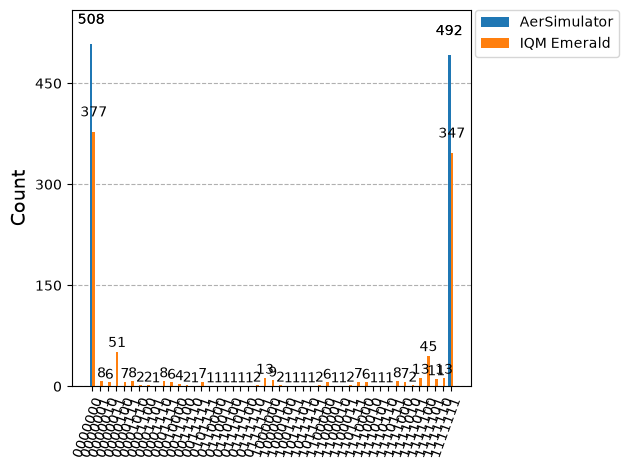

In [11]:
large_hw_counts = large_hw_job.result().get_counts()

plot_histogram([local_counts, large_hw_counts], legend=["AerSimulator", "IQM Emerald"])

That's noisier. All those unwanted bitstrings are part of the noise being added as the depth of the circuit increases.

In [12]:
circuit.depth()

3

In [13]:
large_circ.depth()

8

In [14]:
large_iqm.depth()

25